# 03 — Probabilistic Generative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Fit a **latent-variable generative model** — a Gaussian Mixture Model (GMM) — by maximum likelihood
- Use **held-out log-likelihood** to evaluate and select between generative models
- **Sample new data** from a fitted probabilistic model and compare it with the real data

## 🔗 Prerequisites

### 📊 Data used in this notebook

**The real iris dataset** (`sklearn.datasets.load_iris`) — 150 flowers measured by the botanist Edgar Anderson in 1935 and used by R. A. Fisher in the paper that founded discriminant analysis. We model two of the four real measurements, **petal length and petal width (cm)**.

This dataset earns its place here for one reason: it has a **known number of real groups** — three iris species — that the model is *not told about*. That turns "how many components?" from a rigged question into a genuine test of likelihood-based model selection. A dataset drawn from three Gaussians we invented ourselves could only ever confirm what we already put in.

### 🔗 Prerequisites

- ✅ Examples 01–02
- ✅ Probability basics: Gaussian distributions, likelihood (Course 03)
- ✅ scikit-learn basics (Course 04)

---

## Introduction

A **probabilistic generative model** writes down p(x) explicitly and fits it by **maximizing likelihood**. The simplest interesting one is the **Gaussian Mixture Model**:

p(x) = Σₖ p(z = k) · p(x | z = k),  with each p(x|z=k) a Gaussian.

Here `z` is a **latent variable** — "which component produced this point?" — which we never observe. This is exactly the structure a VAE (example 04) scales up: the VAE replaces the K discrete components with a continuous latent vector and the Gaussians with neural networks, and maximizes a lower bound (ELBO) on this same log-likelihood.


## Fitting and Comparing Models

We fit GMMs with 1–5 components on the real petal measurements and score each in two ways:

- **Held-out log-likelihood** — how much probability the model assigns to *unseen* real flowers (higher = better). This is the standard way to compare probabilistic generative models.
- **BIC** (Bayesian Information Criterion) — likelihood *minus a penalty for model size* (lower = better). Useful because held-out likelihood often keeps creeping up slightly as you add components; BIC asks whether the extra components pay for themselves.

The species labels stay in a locked drawer: the GMM is fitted on the measurements alone. Only after selection do we check the chosen K against the three species that are actually in the data.


In [1]:
# WHAT/WHY: fit Gaussian Mixture Models with different numbers of components
# on REAL flower measurements, then use held-out log-likelihood and BIC to
# choose the best model — demonstrating that likelihood is both the training
# signal and the yardstick. The iris data contains three real species, so the
# selected K can be checked against a ground truth the model never saw.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# ── REAL DATA: Anderson's iris measurements (150 flowers, 1935) ───────────
# We keep two of the four real features so the density is easy to plot.
iris = load_iris()
X = iris.data[:, 2:4]                      # petal length, petal width (cm)
y_true = iris.target                       # species labels — NOT given to the GMM
FEAT = [iris.feature_names[2], iris.feature_names[3]]
print(f'Real dataset: {X.shape[0]} iris flowers, features = {FEAT}')
print(f'Species actually present: {dict(zip(iris.target_names, np.bincount(y_true)))}')
print(f'petal length range: {X[:,0].min():.1f}–{X[:,0].max():.1f} cm | '
      f'petal width range: {X[:,1].min():.1f}–{X[:,1].max():.1f} cm')

X_tr, X_te, y_tr, y_te = train_test_split(X, y_true, test_size=0.3, random_state=0)
print(f'train: {len(X_tr)} flowers | held-out: {len(X_te)} flowers')

# ── Fit K = 1..5; score held-out log-likelihood AND BIC for each ──────────
# Held-out LL rewards fit to unseen data; BIC additionally penalizes model
# size, guarding against "one more component always helps a little".
print("\nK   held-out avg log-likelihood      BIC (lower = better)")
ll, bic = {}, {}
for k in range(1, 6):
    gmm = GaussianMixture(n_components=k, random_state=0).fit(X_tr)
    ll[k]  = gmm.score(X_te)     # mean log p(x) per held-out flower
    bic[k] = gmm.bic(X_tr)       # Bayesian Information Criterion on train
    print(f"{k}          {ll[k]:+.4f}                {bic[k]:,.1f}")

# ── Select K (computed, not assumed) ──────────────────────────────────────
best_k   = min(bic, key=bic.get)
best_k_ll = max(ll, key=ll.get)
print(f"\nBIC selects K = {best_k}; held-out log-likelihood also peaks at K = {best_k_ll}.")
print(f"The data really does contain {len(iris.target_names)} species "
      f"({', '.join(iris.target_names)}) — and the model recovered that count")
print("from the measurements alone, without ever seeing a label.")
gmm = GaussianMixture(n_components=best_k, random_state=0).fit(X_tr)


Real dataset: 150 iris flowers, features = ['petal length (cm)', 'petal width (cm)']
Species actually present: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}
petal length range: 1.0–6.9 cm | petal width range: 0.1–2.5 cm
train: 105 flowers | held-out: 45 flowers

K   held-out avg log-likelihood      BIC (lower = better)
1          -1.9298                396.8
2          -1.3260                250.2
3          -1.2838                247.1
4          -1.3618                256.8
5          -1.3814                271.1

BIC selects K = 3; held-out log-likelihood also peaks at K = 3.
The data really does contain 3 species (setosa, versicolor, virginica) — and the model recovered that count
from the measurements alone, without ever seeing a label.


## Part 2 — Generate New Data From the Fitted Model

A fitted probabilistic model is a **generator**: sampling means (1) draw the latent component `z` from its learned weights, then (2) draw x from that component's Gaussian. We plot real vs generated points over the model's learned density.


Samples drawn per latent component z: [62, 64, 74]
Generated petal length: mean 3.88 cm, std 1.82   (real held-out: mean 3.59, std 1.66)
Generated petal width : mean 1.24 cm, std 0.78   (real held-out: mean 1.13, std 0.71)

Physically impossible samples (a negative measurement): 1/200 = 0.5%
The model knows nothing about botany, only about Gaussians.


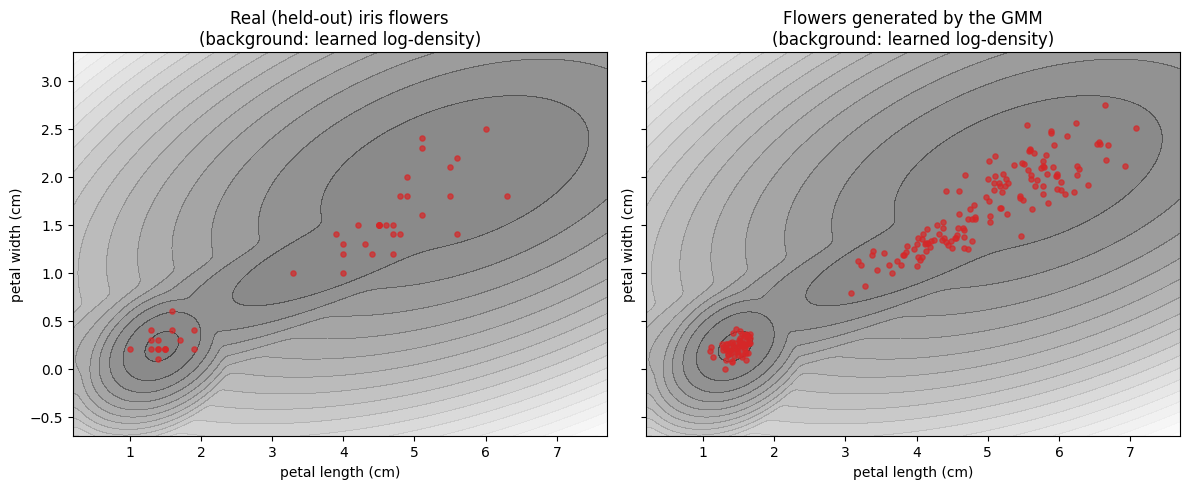


Sampling procedure: draw latent z ~ learned weights, then x ~ Gaussian(z).
A VAE (example 04) does exactly this with a continuous z and neural networks.


In [2]:
# WHAT/WHY: sample brand-new flowers from the fitted GMM and compare them with
# the real held-out measurements on top of the model's learned density — the
# visual test of a generative model: do its samples look like the data?

# ── Sample 200 new points; .sample also returns each point's latent z ─────
X_new, z_new = gmm.sample(200)
counts = np.bincount(z_new, minlength=gmm.n_components)
print("Samples drawn per latent component z:", counts.tolist())
print(f"Generated petal length: mean {X_new[:,0].mean():.2f} cm, std {X_new[:,0].std():.2f}"
      f"   (real held-out: mean {X_te[:,0].mean():.2f}, std {X_te[:,0].std():.2f})")
print(f"Generated petal width : mean {X_new[:,1].mean():.2f} cm, std {X_new[:,1].std():.2f}"
      f"   (real held-out: mean {X_te[:,1].mean():.2f}, std {X_te[:,1].std():.2f})")

# ── Honesty check that only real data can give you ────────────────────────
# A Gaussian has infinite support, so the model can generate a NEGATIVE petal
# width - physically impossible for a flower. Count how often that happens.
impossible = int((X_new < 0).any(axis=1).sum())
print(f"\nPhysically impossible samples (a negative measurement): "
      f"{impossible}/{len(X_new)} = {impossible/len(X_new):.1%}")
print("The model knows nothing about botany, only about Gaussians.")

# ── Evaluate the learned density p(x) on a grid for the background ────────
pad = 0.8
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-pad, X[:,0].max()+pad, 200),
                     np.linspace(X[:,1].min()-pad, X[:,1].max()+pad, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
log_dens = gmm.score_samples(grid).reshape(xx.shape)  # log p(x) at each grid point

# ── Plot: real data (left) vs generated data (right), same density map ────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, pts, title in [(axes[0], X_te, "Real (held-out) iris flowers"),
                       (axes[1], X_new, "Flowers generated by the GMM")]:
    ax.contourf(xx, yy, log_dens, levels=20, cmap="Greys", alpha=0.5)
    ax.scatter(pts[:, 0], pts[:, 1], s=14, alpha=0.7, c="tab:red")
    ax.set_xlabel(FEAT[0]); ax.set_ylabel(FEAT[1])
    ax.set_title(title + "\n(background: learned log-density)")
plt.tight_layout(); plt.show()

print("\nSampling procedure: draw latent z ~ learned weights, then x ~ Gaussian(z).")
print("A VAE (example 04) does exactly this with a continuous z and neural networks.")


## From GMM to VAE

| | GMM (this notebook) | VAE (example 04) |
|---|---|---|
| Latent variable | discrete z ∈ {1..K} | continuous vector z |
| p(x\|z) | fixed-form Gaussian | neural network decoder |
| Inference | exact (EM algorithm) | learned encoder + reparameterization |
| Objective | exact log-likelihood | ELBO (a lower bound on log-likelihood) |

Keep the held-out log-likelihood idea in mind: it returns in example 10 as the basis of evaluation metrics for generative models.


## 📚 References & Further Reading

**Textbooks:**
- Bishop (2006) — *Pattern Recognition and Machine Learning*, Ch. 9 (Mixture Models and EM)
- Goodfellow, Bengio & Courville (2016) — [Deep Learning Book](https://www.deeplearningbook.org/), Ch. 20 (Deep Generative Models)

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) *(the VAE — the deep version of this notebook's idea)*

**Survey:**
- Bond-Taylor et al. (2021) — [Deep Generative Modelling: A Comparative Review](https://arxiv.org/abs/2103.04922) *(where mixture models sit in the modern generative landscape)*


## 📝 Summary

In this notebook you fitted a **Gaussian Mixture Model** — a genuine latent-variable generative model — by maximum likelihood on **real iris petal measurements**, compared models with **held-out log-likelihood and BIC**, and **sampled new flowers** from the fitted model.

Read the printed table: both criteria select **K = 3**, and the iris data really does contain three species. The model recovered the number of real groups from the measurements alone, with the labels never shown to it — a claim you can only make on data whose structure you did not put there yourself.

Then read the honesty check below the samples: a Gaussian has infinite support, so the fitted model happily generates flowers with a *negative* petal width. Its density is a good description of the data and still assigns probability to the impossible. Real measurements make that limitation visible; an invented Gaussian cloud centred far from zero would have concealed it.

These are the same three moves (fit p(x), evaluate likelihood, sample) that every deep generative model in this course repeats at scale.
